In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.optimizers import Adam

# Load CIFAR-10 Dataset

In [2]:
# Load dataset
(x_train, _), (x_test, _) = cifar10.load_data()

# Normalize images
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)

C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training Data Shape: (50000, 32, 32, 3)
Testing Data Shape: (10000, 32, 32, 3)


# Add Random Noise to Images

In [3]:
# Noise factor
noise_factor = 0.2

# Add noise
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape)

# Clip pixel values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

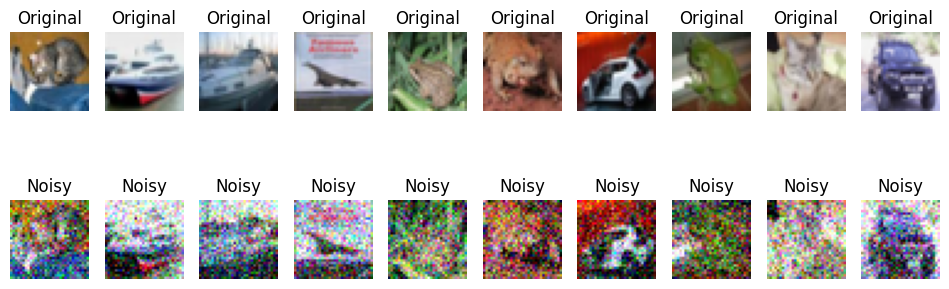

In [4]:
plt.figure(figsize=(12,4))

for i in range(10):
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.axis("off")

    ax = plt.subplot(2, 10, i + 11)
    plt.imshow(x_test_noisy[i])
    plt.title("Noisy")
    plt.axis("off")

plt.show()

# Autoencoder Model Code

In [5]:
# Input layer
input_img = Input(shape=(32, 32, 3))

# -------- Encoder --------
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# -------- Decoder --------
x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

# Create model
autoencoder = Model(input_img, decoded)

# Compile model
autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')

# Model summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 32, 32, 3)           │             867 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 45s 107ms/step - loss: 0.5778 - val_loss: 0.5690
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 101ms/step - loss: 0.5669 - val_loss: 0.5664
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 45s 116ms/step - loss: 0.5650 - val_loss: 0.5656
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 51s 131ms/step - loss: 0.5640 - val_loss: 0.5643
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - loss: 0.5633 - val_loss: 0.5637
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - loss: 0.5629 - val_loss: 0.5634
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 106ms/step - loss: 0.5625 - val_loss: 0.5635
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 106ms/step - loss: 0.5621 - val_loss: 0.5626
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - loss: 0.5617 - val_loss: 0.5623
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 21762s 56s/step - loss: 0.5614 - val_loss: 0.5619


# Denoise Test Images

In [7]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 49930s 160s/step


# Visualization

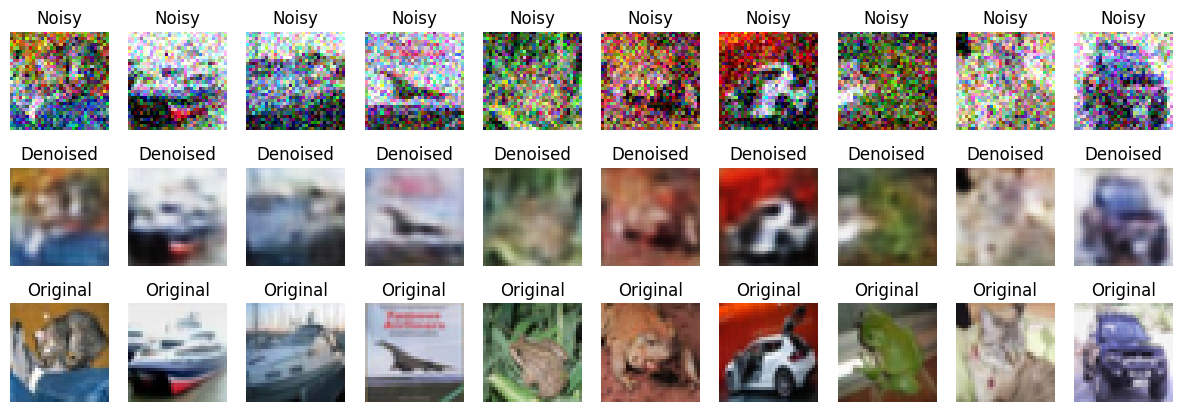

In [8]:
plt.figure(figsize=(15,5))

for i in range(10):

    # Noisy image
    ax = plt.subplot(3, 10, i + 1)
    plt.imshow(x_test_noisy[i])
    plt.title("Noisy")
    plt.axis("off")

    # Denoised image
    ax = plt.subplot(3, 10, i + 11)
    plt.imshow(decoded_imgs[i])
    plt.title("Denoised")
    plt.axis("off")

    # Original image
    ax = plt.subplot(3, 10, i + 21)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.axis("off")

plt.show()

# second probelem statement of assignment

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    Flatten,
    Dense,
    Reshape,
    Conv2DTranspose,
    Lambda
)

from tensorflow.keras.models import Model
from tensorflow.keras import backend as K

In [12]:
# Load dataset
(x_train, _), (x_test, _) = cifar10.load_data()

# Normalize pixel values
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

Training Shape: (50000, 32, 32, 3)
Testing Shape: (10000, 32, 32, 3)


In [13]:
# Input image
input_img = Input(shape=(32, 32, 3))

In [14]:
# Convolution layers
x = Conv2D(
    32,
    3,
    activation='relu',
    strides=2,
    padding='same'
)(input_img)

x = Conv2D(
    64,
    3,
    activation='relu',
    strides=2,
    padding='same'
)(x)

In [15]:
# Save shape
shape_before_flattening = K.int_shape(x)[1:]

# Flatten layer
x = Flatten()(x)

# Dense layer
x = Dense(128, activation='relu')(x)

In [16]:
# Latent dimension
latent_dim = 2

# Mean and variance
z_mean = Dense(latent_dim)(x)
z_log_var = Dense(latent_dim)(x)

# Sampling Function

In [17]:
def sampling(args):

    z_mean, z_log_var = args

    epsilon = K.random_normal(
        shape=(K.shape(z_mean)[0], latent_dim)
    )

    return z_mean + K.exp(z_log_var / 2) * epsilon

# Latent vector
z = Lambda(sampling)([z_mean, z_log_var])

# Create Encoder Model

In [18]:
encoder = Model(
    input_img,
    [z_mean, z_log_var, z],
    name="encoder"
)

encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 32, 32, 3)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 16, 16, 32)        │             896 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 8, 8, 64)          │          18,496 │ conv2d_5[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 4096)              │               0 │ conv2d_6[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 128)               │         524,416 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 2)                 │             258 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 2)                 │             258 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda (Lambda)               │ (None, 2)                 │               0 │ dense_1[0][0],             │
│                               │                           │                 │ dense_2[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 544,324 (2.08 MB)

 Trainable params: 544,324 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

# Build Decoder

In [19]:
int(np.prod(shape_before_flattening))

4096

In [20]:
# Decoder input
latent_inputs = Input(shape=(latent_dim,))

In [21]:
# Dense layer
x = Dense(
    int(np.prod(shape_before_flattening)),
    activation='relu'
)(latent_inputs)

In [22]:
# Reshape layer
x = Reshape(shape_before_flattening)(x)

In [23]:
# Deconvolution layers
x = Conv2DTranspose(
    64,
    3,
    activation='relu',
    strides=2,
    padding='same'
)(x)

x = Conv2DTranspose(
    32,
    3,
    activation='relu',
    strides=2,
    padding='same'
)(x)

# Output layer
decoder_outputs = Conv2DTranspose(
    3,
    3,
    activation='sigmoid',
    padding='same'
)(x)


In [24]:
# Decoder model
decoder = Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 2)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4096)                │          12,288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose (Conv2DTranspose)   │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_1 (Conv2DTranspose) │ (None, 32, 32, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_2 (Conv2DTranspose) │ (None, 32, 32, 3)           │             867 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 68,547 (267.76 KB)

 Trainable params: 68,547 (267.76 KB)

 Non-trainable params: 0 (0.00 B)

# Create Custom VAE Class

In [77]:
class VAE(tf.keras.Model):

    def __init__(self, encoder, decoder, **kwargs):

        super(VAE, self).__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder

        # Metrics
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")

        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(
            name="reconstruction_loss"
        )

        self.kl_loss_tracker = tf.keras.metrics.Mean(
            name="kl_loss"
        )

    @property
    def metrics(self):

        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    # Forward pass
    def call(self, inputs):

        z_mean, z_log_var, z = self.encoder(inputs)

        reconstruction = self.decoder(z)

        return reconstruction

    # Training step
    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            # Encode
            z_mean, z_log_var, z = self.encoder(data)

            # Decode
            reconstruction = self.decoder(z)

            # Reconstruction loss
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(
                        data,
                        reconstruction
                    ),
                    axis=(1, 2)
                )
            )

            # KL divergence
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            # Total loss
            total_loss = reconstruction_loss + kl_loss

        # Gradients
        grads = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        # Apply gradients
        self.optimizer.apply_gradients(
            zip(grads, self.trainable_weights)
        )

        # Update metrics
        self.total_loss_tracker.update_state(total_loss)

        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )

        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss":
                self.reconstruction_loss_tracker.result(),
            "kl_loss":
                self.kl_loss_tracker.result(),
        }

    # Validation step
    def test_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        # Encode
        z_mean, z_log_var, z = self.encoder(data)

        # Decode
        reconstruction = self.decoder(z)

        # Reconstruction loss
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(
                    data,
                    reconstruction
                ),
                axis=(1, 2)
            )
        )

        # KL loss
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var),
                axis=1
            )
        )

        # Total loss
        total_loss = reconstruction_loss + kl_loss

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

# Create VAE Model

In [78]:
vae = VAE(encoder, decoder)

# Compile Model

In [79]:
vae.compile(optimizer='adam')

# Train Model

In [80]:
vae.fit(
    x_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, None)
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 38s 87ms/step - kl_loss: 4.0084 - loss: 656.0370 - reconstruction_loss: 652.0284 - val_kl_loss: 0.0000e+00 - val_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 110ms/step - kl_loss: 4.0263 - loss: 654.9745 - reconstruction_loss: 650.9483 - val_kl_loss: 0.0000e+00 - val_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 47s 120ms/step - kl_loss: 4.0277 - loss: 654.8925 - reconstruction_loss: 650.8646 - val_kl_loss: 0.0000e+00 - val_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 118ms/step - kl_loss: 4.0526 - loss: 654.7427 - reconstruction_loss: 650.6901 - val_kl_loss: 0.0000e+00 - val_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 118ms/step - kl_loss: 4.0667 - loss: 654.6022 - reconstruction_loss: 650.5353 - val_kl_loss: 0.0000e+00 - val_loss: 0.000

# Reconstruct Images

In [81]:
# Encode test images
z_mean, z_log_var, z = encoder.predict(x_test)

# Decode images
reconstructed_images = decoder.predict(z)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


# Display Results

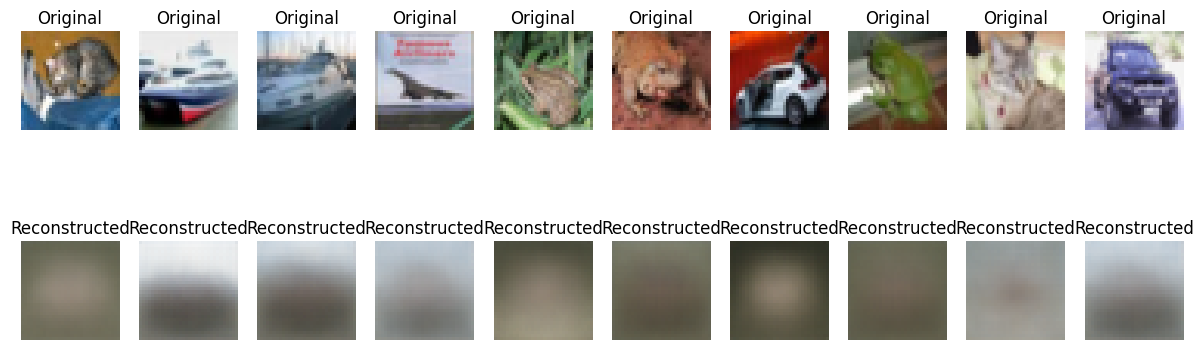

In [82]:
plt.figure(figsize=(15,5))

for i in range(10):

    # Original image
    ax = plt.subplot(2, 10, i + 1)

    plt.imshow(x_test[i])

    plt.title("Original")

    plt.axis("off")

    # Reconstructed image
    ax = plt.subplot(2, 10, i + 11)

    plt.imshow(reconstructed_images[i])

    plt.title("Reconstructed")

    plt.axis("off")

plt.show()